**VIX in the one-factor Bergomi model**

# Imports

In [4]:
# TODO: try to calibrate the single case model to VIX data

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import matplotlib.pyplot as plt
from bergomi import OneFactorBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import xi0_heston, relative_error

sns.set_theme(context="talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
COLORS = sns.color_palette("tab10")

In [158]:
mats = {
    # "1W": 7 / 365.0,
    "1M": 1.0 / 12.0,
    "3M": 3.0 / 12.0,
    "6M": 6.0 / 12.0,
    # "1Y": 1.0,
}

# Single case

## VIX implied volatility

In [ ]:
# model parameters
params = {"w": 2.0, "k": 0.25}  # set 1
params = {"w": 8.0, "k": 10}  # set 2, from Guyon, "The VIX Future in Bergomi Models"

rho = -0.7
xi0 = lambda u: np.ones_like(u) * 0.24**2
# xi0 = lambda t: xi0_heston(t, shape="contango")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params)

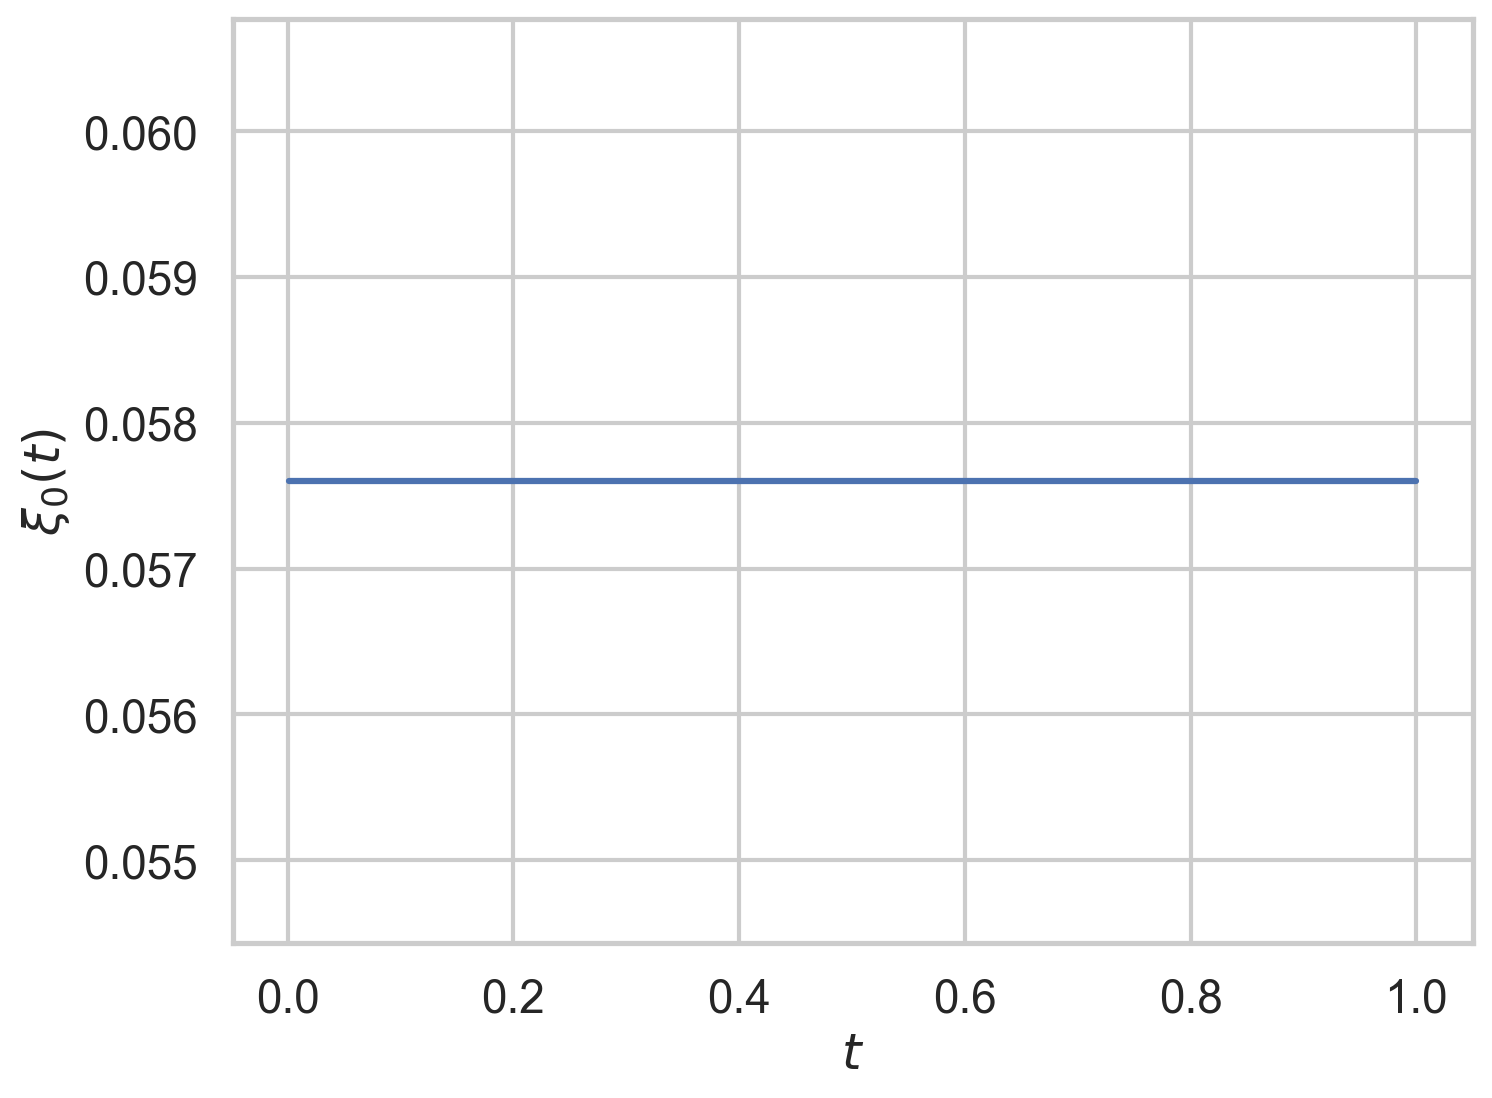

In [235]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, onebergomi.xi0(ts))
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [236]:
# log moneyness
ks = np.linspace(-0.1, 0.4, 10)

In [237]:
# VIX implied volatilities via quadrature
n_quad = 120
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad)
    for month, T in mats.items()
}
impvol_vix

{'1M': array([1.80617452, 1.81172013, 1.81720853, 1.82299256, 1.82870746,
        1.83438659, 1.84002995, 1.8455708 , 1.85131192, 1.85712218]),
 '3M': array([1.14377558, 1.14729822, 1.15085185, 1.15442932, 1.15800917,
        1.16154253, 1.16497338, 1.16871059, 1.17214859, 1.1758703 ]),
 '6M': array([0.81121743, 0.81371844, 0.8162421 , 0.81878245, 0.82132399,
        0.82382858, 0.82626522, 0.82891285, 0.83133996, 0.83398879])}

In [238]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: onebergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [239]:
impvol_vix_approx

{'1M': array([1.79846108, 1.80487216, 1.81117833, 1.81739748, 1.82354629,
        1.82963669, 1.8356818 , 1.84168756, 1.84766114, 1.85360253]),
 '3M': array([1.13721311, 1.14136398, 1.14543974, 1.14945233, 1.15341246,
        1.15733087, 1.16121352, 1.16506755, 1.16889656, 1.1727041 ]),
 '6M': array([0.80653012, 0.80947578, 0.81236899, 0.8152169 , 0.81802785,
        0.82080781, 0.82356274, 0.8262974 , 0.82901418, 0.83171666])}

In [240]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: onebergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

In [241]:
impvol_vix_expansion

{'1M': array([1.81515249, 1.82117016, 1.82718782, 1.83320549, 1.83922316,
        1.84524083, 1.8512585 , 1.85727617, 1.86329384, 1.86931151]),
 '3M': array([1.15003043, 1.15387507, 1.15771971, 1.16156435, 1.16540899,
        1.16925364, 1.17309828, 1.17694292, 1.18078756, 1.1846322 ]),
 '6M': array([0.81567761, 0.81840533, 0.82113304, 0.82386076, 0.82658847,
        0.82931619, 0.8320439 , 0.83477162, 0.83749933, 0.84022705])}

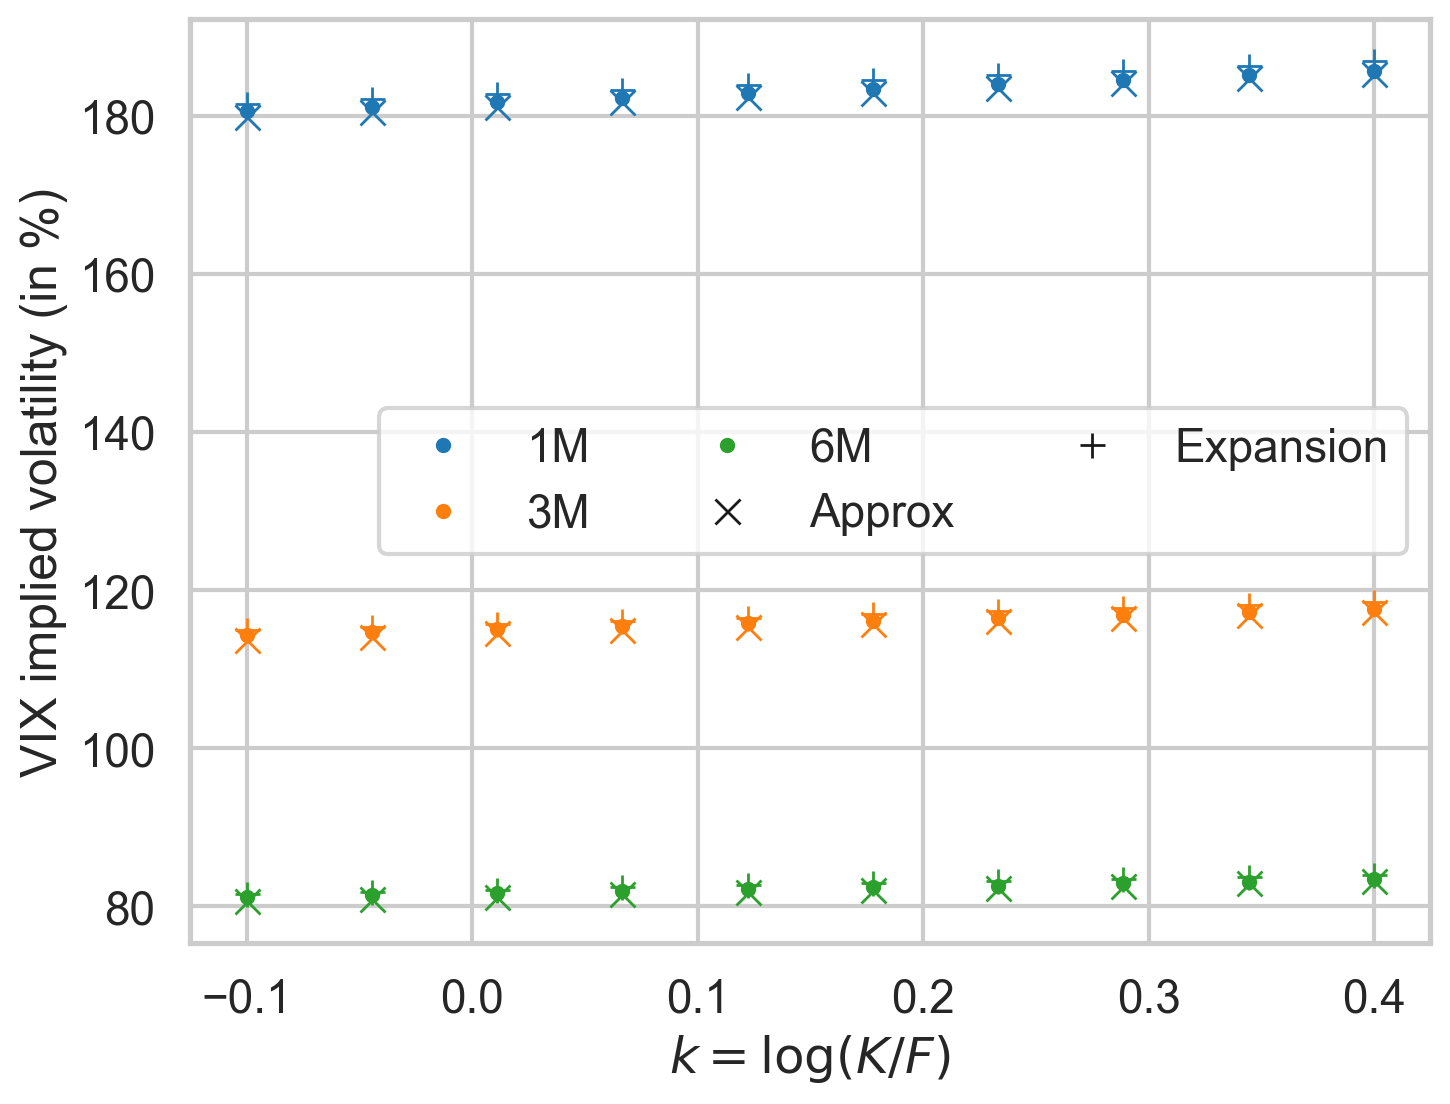

In [ ]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 100 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 100 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 100 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility (in %)")
ax.legend(ncol=3)
# ax.set_ylim(92, 100)
# fig.savefig("figures/vix_one_bergomi_set_2.pdf", bbox_inches="tight")
plt.show()

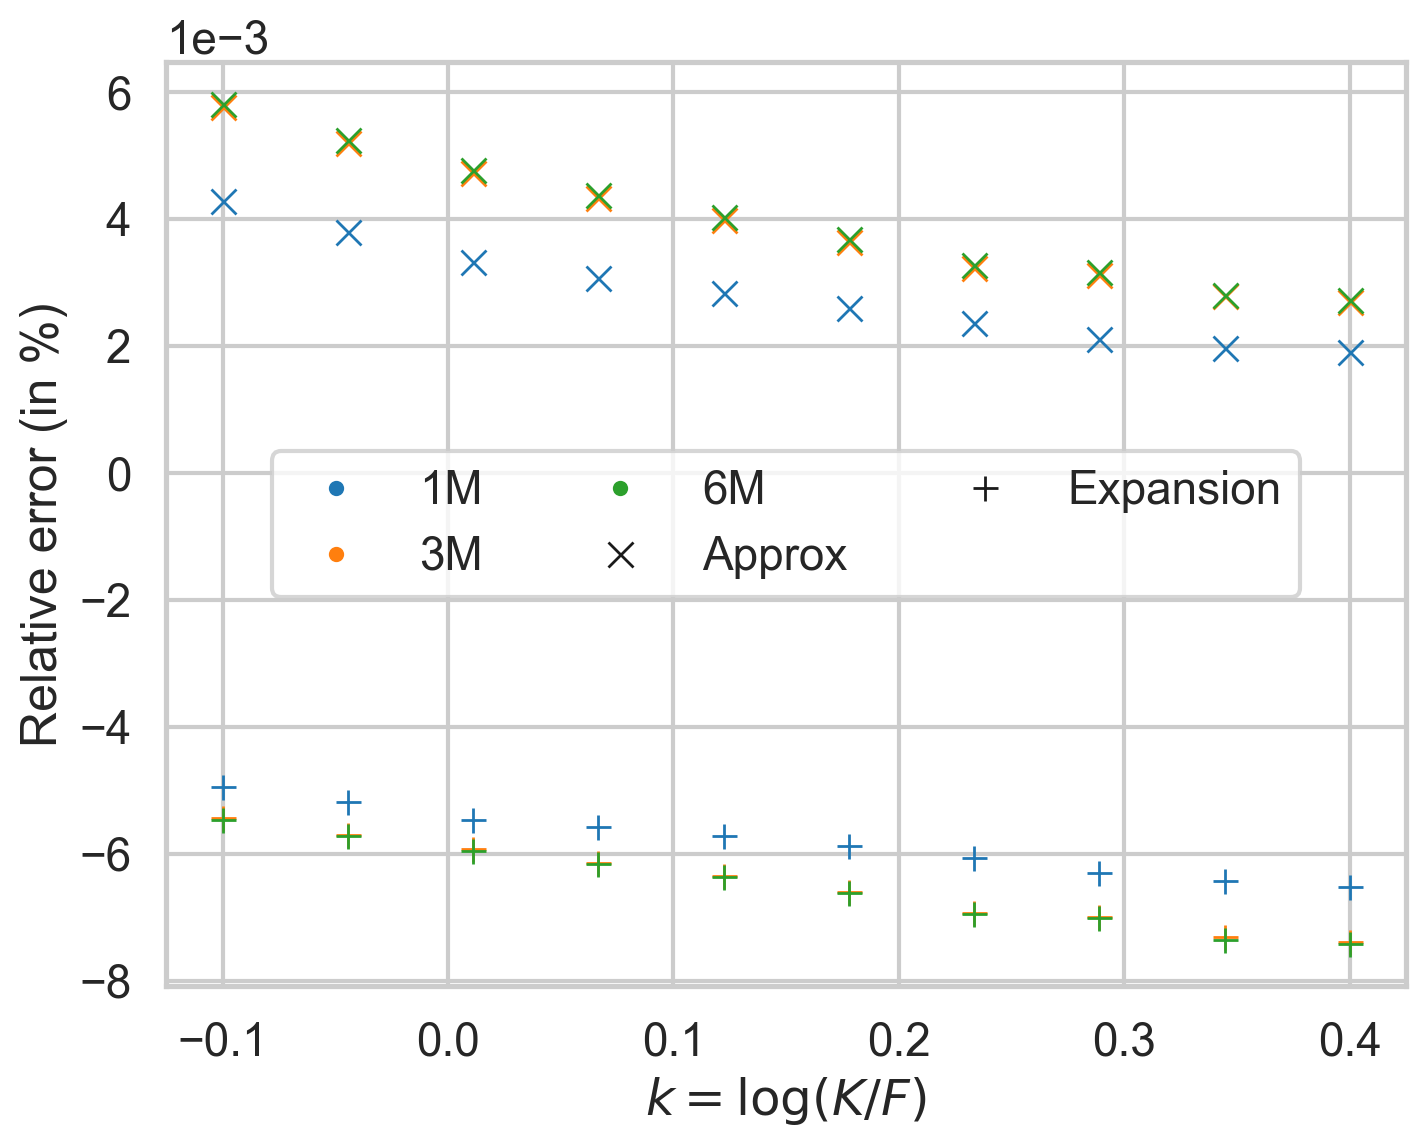

In [ ]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_approx[month], impvol_vix[month]) for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_expansion[month], impvol_vix[month]) for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error (in %)")
ax.legend(loc="center", ncol=3)
# ax.set_ylim(-4e-4, 2e-4)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
# fig.savefig("figures/vix_one_bergomi_error_set_2.pdf", bbox_inches="tight")
plt.show()

# Mixed case

In [25]:
params = {"w": 3.5, "k": 4.0}

rho = -0.7
xi0 = lambda u: np.ones_like(u) * 0.235**2
# xi0 = lambda t: xi0_heston(t, shape="contango")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params)

lbd = 0.2
w_2 = 0.6
ks = np.linspace(-0.1, 0.6, 15)

In [26]:
# VIX implied volatilities
n_quad = 120
impvol_vix_mixed = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad, lbd=lbd, w_2=w_2)
    for month, T in mats.items()
}

In [27]:
# Weak approximation
impvol_vix_mixed_approx = {
    month: np.asarray(
        onebergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0, n_quad=n_quad
        )
    )
    for month, T in mats.items()
}

In [28]:
# Hermite series
impvol_vix_mixed_approx_series = {
    month: np.asarray(
        onebergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0, n_trunc_herm=4
        )
    )
    for month, T in mats.items()
}

In [29]:
# maybe adjust formula depending on call/put and sigma_1 / sigma_2
# TODO: try to start from formula directly and use hermite expansion

implied_vol_vix_expansion = {
    month: np.array(
        [
            onebergomi.implied_vol_vix_expansion_mixed(
                k=k, T=T, lbd=lbd, volvol_2=w_2, n_trunc_herm=6, opt=3
            )
            for k in ks
        ]
    )
    for month, T in mats.items()
}

In [30]:
# # Lognormal approximation
# impvol_vix_mixed_approx_lognorm = {
#     month: np.asarray(
#         onebergomi.implied_vol_vix_lognorm_approx_mixed(
#             lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
#         )
#     )
#     for month, T in mats.items()
# }

In [31]:
# # Shifted Lognormal approximation
# impvol_vix_mixed_approx_slognorm = {
#     month: np.asarray(
#         onebergomi.implied_vol_vix_shifted_lognorm_approx_mixed(
#             lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
#         )
#     )
#     for month, T in mats.items()
# }

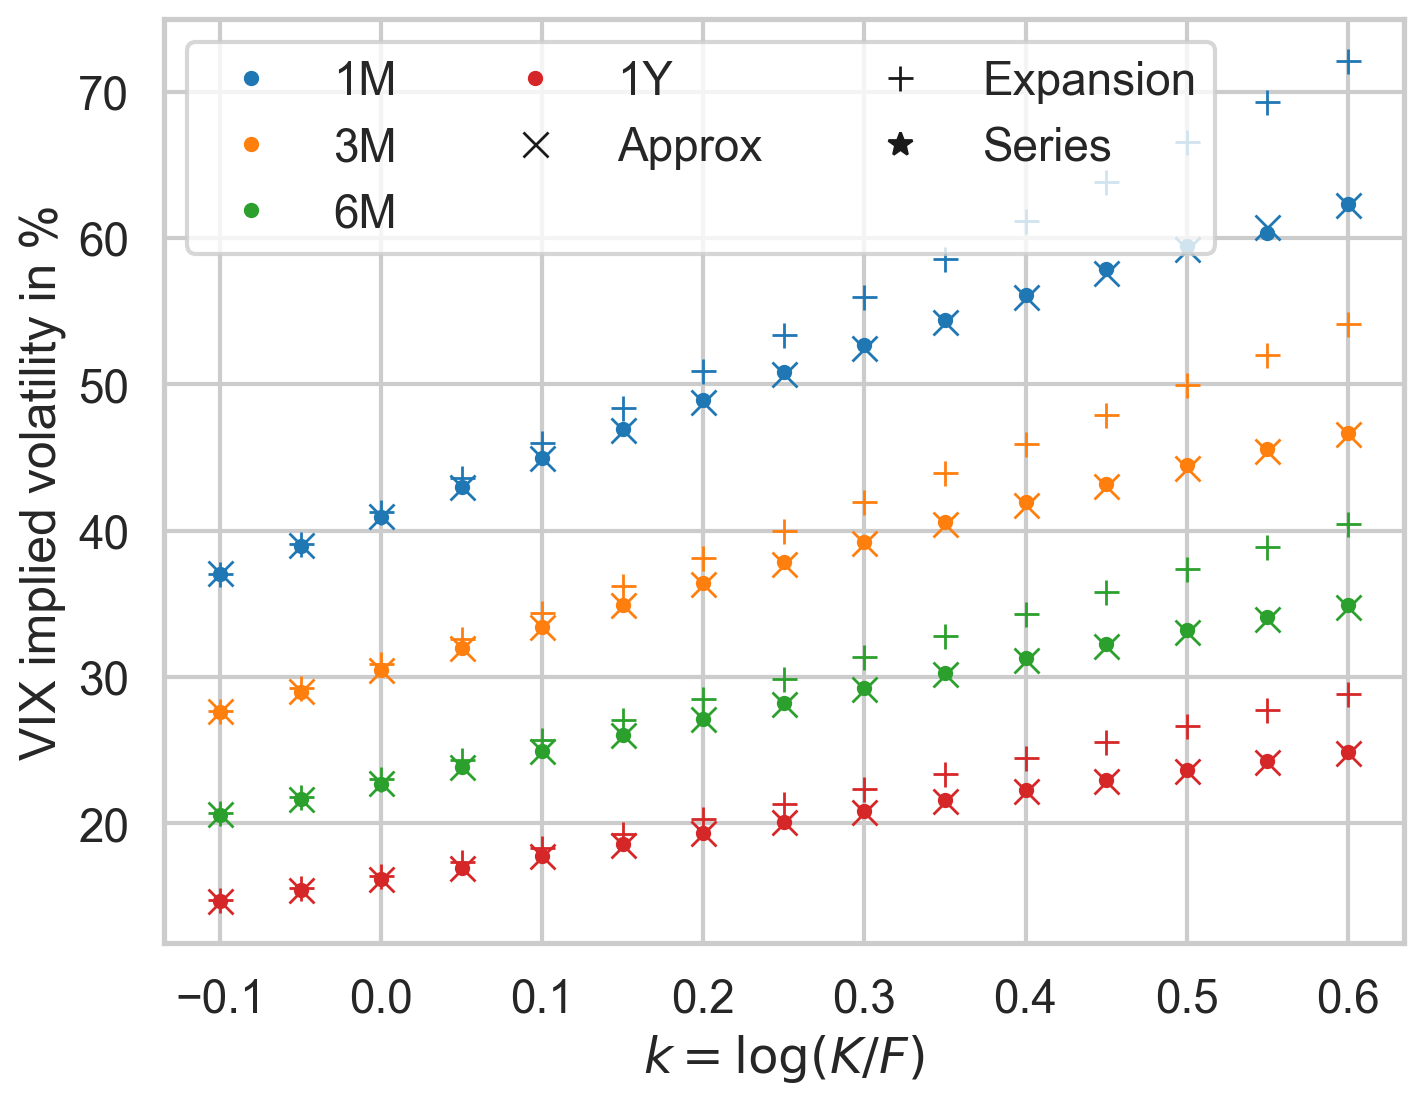

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, month in enumerate(mats.keys()):
    ### True VIX implied volatilities
    ax.plot(
        ks,
        100 * impvol_vix_mixed[month],
        ".",
        color=COLORS[i],
        label=f"{month}",
    )
    ### Weak approximation
    ax.plot(
        ks,
        100 * impvol_vix_mixed_approx[month],
        "x",
        color=COLORS[i],
    )
    # Expansion formula
    ax.plot(
        ks,
        100 * implied_vol_vix_expansion[month],
        "+",
        color=COLORS[i],
    )
    # ## Hermite series approximation
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_series[month],
    #     "*",
    #     color=COLORS[i],
    # )
    ### Lognormal approximation
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_lognorm[month],
    #     "v",
    #     color=COLORS[i],
    # )
    ### Shifted lognormal approximation
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_slognorm[month],
    #     "*",
    #     color=COLORS[i],
    # )
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.plot([], [], "k*", label="Series")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(ncol=3)
# ax.set_ylim(10, 150)
plt.show()

{'1M': array([0.31482451, 0.33447839, 0.35958521, 0.39275117, 0.42756878,
        0.46228312, 0.49608134, 0.52865841, 0.5599352 , 0.58992557,
        0.61867811, 0.64625196, 0.67270704, 0.69809996, 0.72248243]),
 '3M': array([0.23102768, 0.24187945, 0.25704958, 0.28052233, 0.30605324,
        0.33178903, 0.35688303, 0.38104497, 0.40421613, 0.42642005,
        0.44770576, 0.46812691, 0.48773445, 0.50657518, 0.52469067]),
 '6M': array([0.17173503, 0.17893177, 0.18941153, 0.20660181, 0.22555362,
        0.24473805, 0.26345212, 0.28146129, 0.29872242, 0.31525765,
        0.33110742, 0.34631427, 0.36091801, 0.37495438, 0.38845506]),
 '1Y': array([0.12229513, 0.12732457, 0.13469864, 0.14690977, 0.1604018 ,
        0.17406892, 0.18740188, 0.20023141, 0.21252688, 0.22430468,
        0.23559388, 0.24642538, 0.25682751, 0.26682589, 0.27644318])}

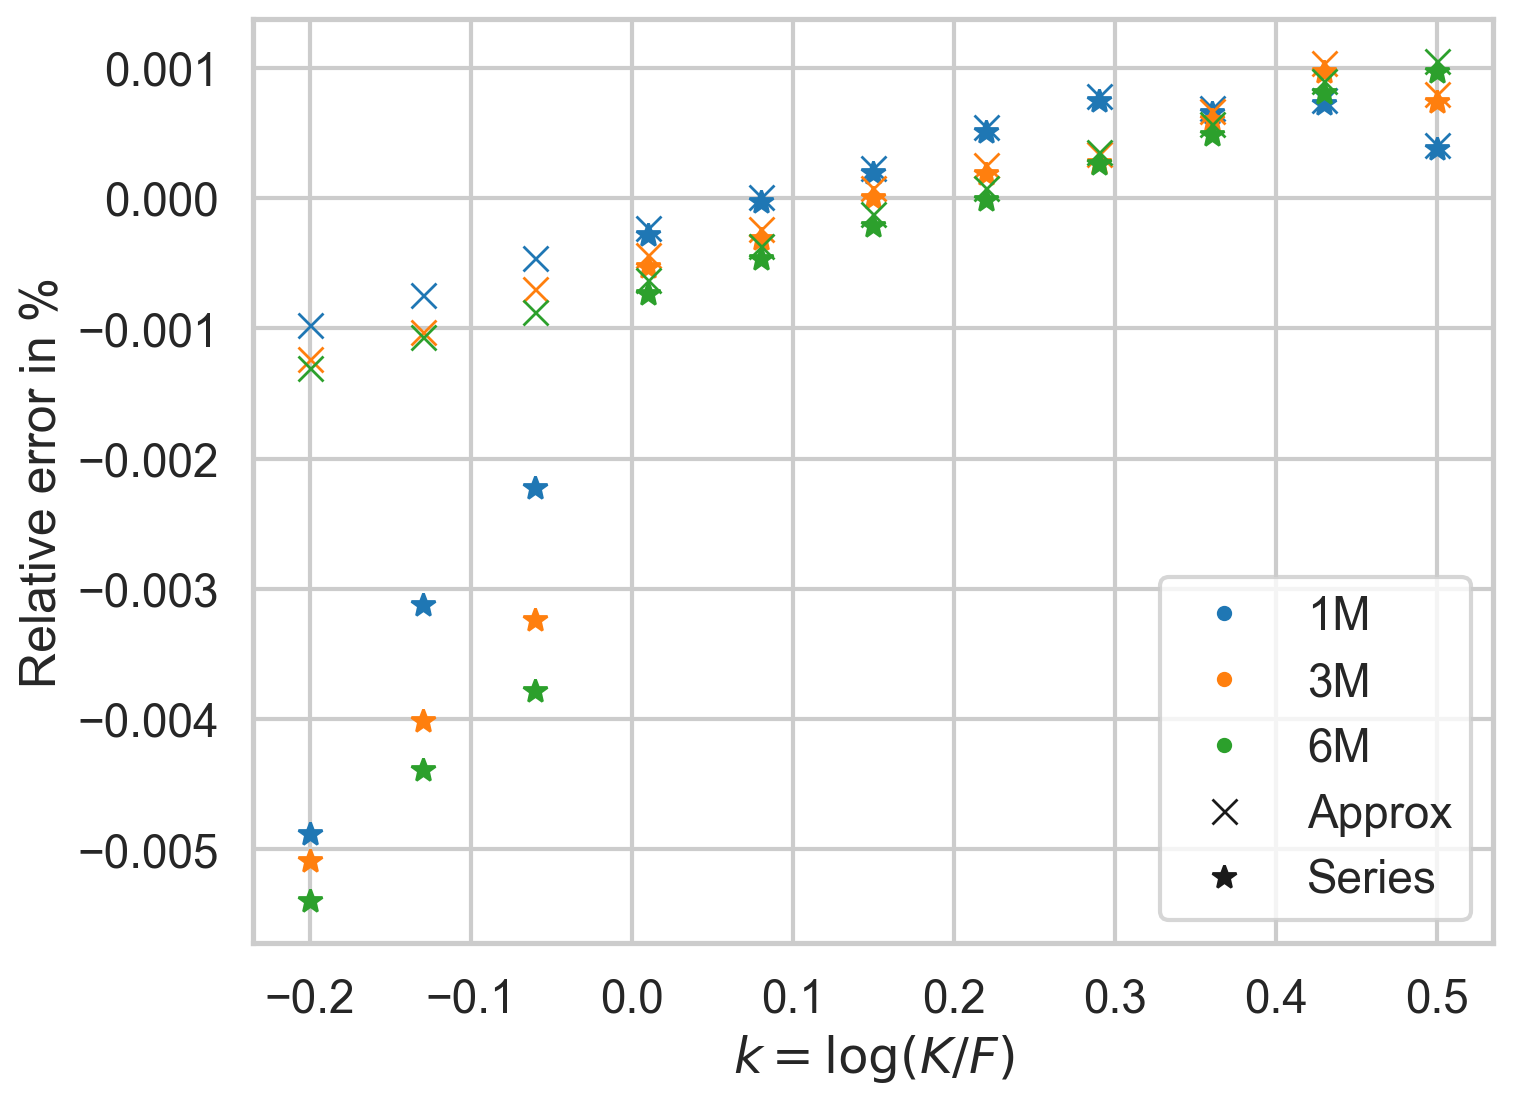

In [106]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_mixed_approx[month], impvol_vix_mixed[month])
    for month in mats
]
rel_error_approx_series = [
    relative_error(impvol_vix_mixed_approx_series[month], impvol_vix_mixed[month])
    for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_approx_series[i], "*", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k*", label="Series")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error in %")
ax.legend(loc="best")
# ax.set_ylim(-1e-3, 1e-3)
plt.show()